In [19]:
%matplotlib inline

import copy
import itertools
import sys
from collections import defaultdict

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import shapely.geometry as geom

sys.path.insert(0, "../")
from weavingspace import (
  KMP_Matcher,
  Symmetries,
  TileShape,
  TileUnit,
  Topology,
  Transform,
  WeaveUnit,
  tiling_utils,
  topology_plot,
)


In [20]:
s = 1000 / np.sqrt(2)
tile = TileUnit(base_shape = TileShape.RECTANGLE, spacing = 1000)
poly = geom.Polygon(
  [(0, 0), (0, s/2), (s/2, s/2), (s/2, -s/2), (-s/2, -s/2), (-s/2, 0)])
tile.tiles = gpd.GeoDataFrame(
  data = {"tile_id": ["a"]}, 
  geometry = gpd.GeoSeries([poly]),
  crs = 3857)
tile.setup_vectors((-s/2, s/2), (s, s/2))
tile.prototile = tile.get_prototile_from_vectors()
tile.regularised_prototile = copy.deepcopy(tile.tiles[["geometry"]])

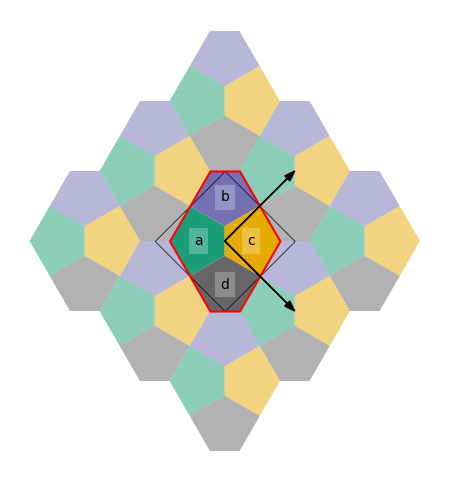

In [21]:
tile = TileUnit(tiling_type = "cairo", n = 3)
# tile = TileUnit(tiling_type = "hex-slice", n = 6, offset = 1)
# tile = TileUnit(tiling_type = "hex-dissection", n = 9, offset = 1, offset_angle = 30)
# tile = TileUnit(tiling_type = "lave", code = "3.12.12")
# tile = TileUnit(tiling_type = "archi", code = "4.8.8")
# tile = TileUnit(tiling_type = "chavey", code = "I")
# tile = TileUnit(tiling_type = "hex-colouring", n = 7)
# tile = TileUnit(tiling_type = "grid", n = 2, nrows = 1, ncols = 2, xy_offset = (0.5, 0))
# tile = tiling_utils.minimise_weave_unit(WeaveUnit(weave_type = "basket", n = 3, strands = "abc|def"))
# tile = TileUnit(base_shape = TileShape.TRIANGLE)
tile.plot(figsize = (6, 6), r = 1, show_vectors = True).set_axis_off()

In [22]:
topo = Topology(tile, ignore_tile_ids = True)

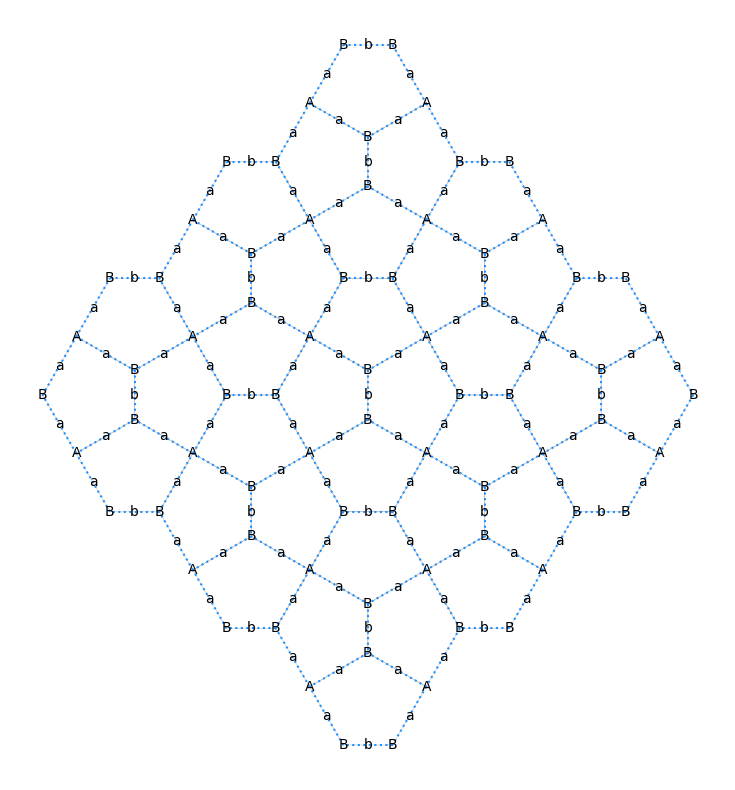

In [23]:
ax = topology_plot.plot(
  topo,
  show_original_tiles = True,
  show_tile_centres = False,
  show_vertex_labels = True,
  show_vertex_ids = False,
  show_edges = True,
  offset_edges = False,
  show_edge_labels = True,
  show_dual_tiles = False,
)

## Modifying a tiling

CAUTION: new Topology will probably not be correctly labelled. To build a correct Topology, extract the tileable attribute and rebuild Topology from that.


<Axes: >

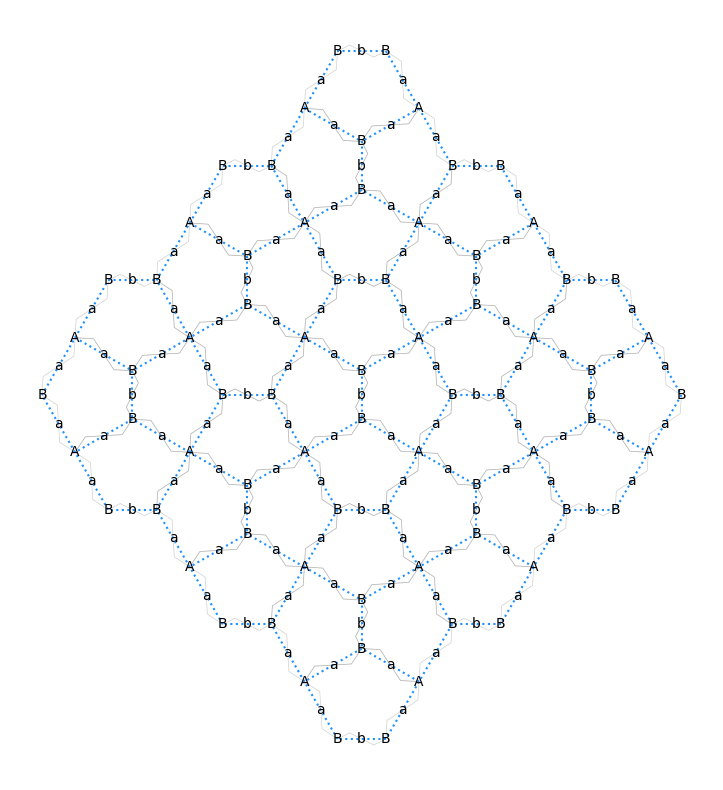

In [24]:
topo2 = topo \
  .transform_geometry(True, True, "abcdefghijklmn", "zigzag_edge", n = 2, h = 0.25, smoothness = 0)
topology_plot.plot(
  topo2,
  show_original_tiles = True,
  show_tile_centres = False,
  show_vertex_labels = True,
  show_vertex_ids = False,
  show_edges = True,
  offset_edges = False,
  show_edge_labels = True,
  show_dual_tiles = False,
)

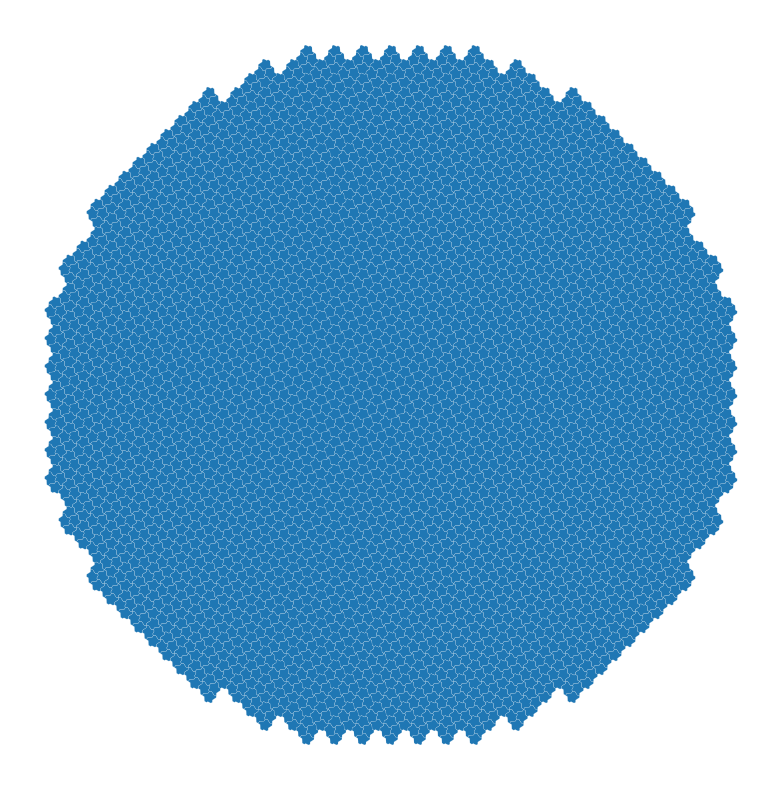

In [25]:
from weavingspace import Tiling

d = gpd.read_file("data/imd-auckland-2018.gpkg").to_crs(topo2.tileable.crs)
tiling = Tiling(topo2.tileable, d)
tiling.tiles.plot(ec = "w", lw = 0.1, figsize = (10, 10)).set_axis_off()

Note that some tiles around the outside might not get 'deformed' correctly because they are unconstrained by neighbours (I think...), but the central tile unit should be fine. To see the potential new tiling we do this:

<Axes: >

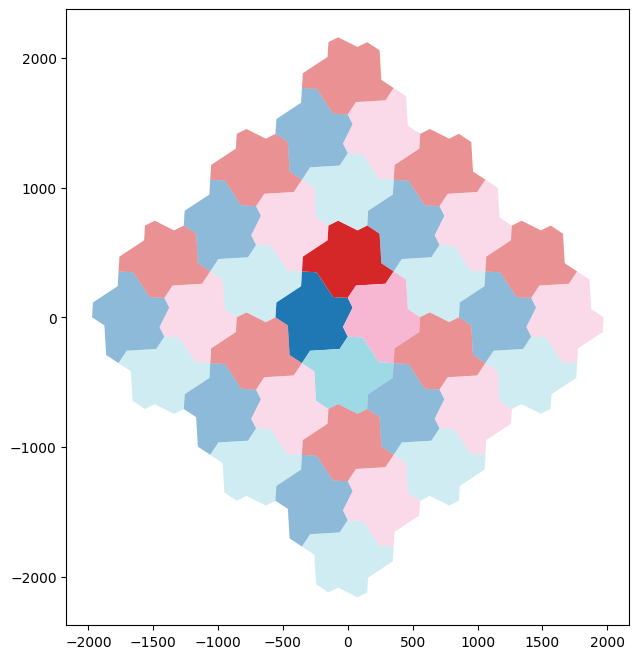

In [26]:
tile_unit = topo2.tileable
tile_unit.plot(r = 1, show_prototile = False, show_reg_prototile = False, 
               r_alpha = 0.5, cmap = "tab20", show_ids = False)

## Dual tiling from the topology

<Axes: >

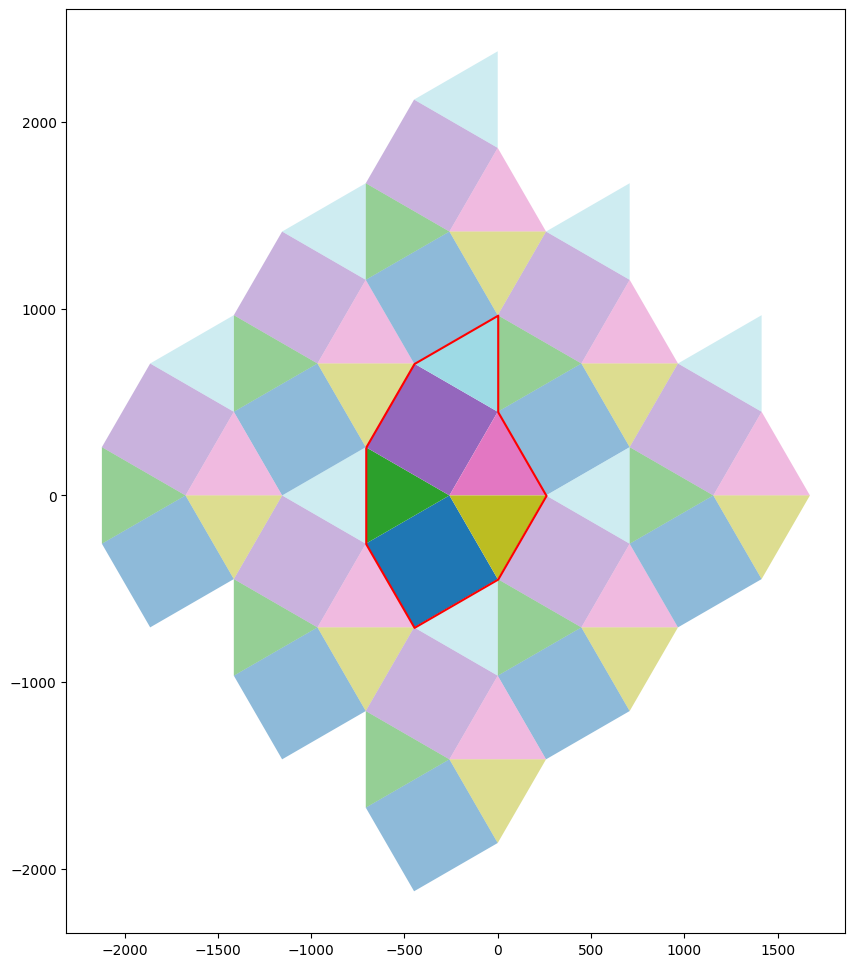

In [27]:
from weavingspace.topology import labels

tile2 = copy.deepcopy(topo.tileable)
dual_tiles = list(topo.dual_tiles.values())
tile2.tiles = gpd.GeoDataFrame(
  data = {"tile_id": labels[:len(dual_tiles)]},
  geometry = gpd.GeoSeries(dual_tiles))
tile2._setup_regularised_prototile(override = True)
tile2.plot(r = 1, show_reg_prototile = True, show_prototile = False, show_vectors = False,
           cmap = "tab20", show_ids = False, figsize = (12, 12)) #, ec = "k")
